# 1 Introduction


SHAFE:JAWAD
LEARNING GOALS

1. Learn how to extend linear regression from one feature to multiple features
2. Understand why feature scaling (z-score normalization) is critical for gradient descent
3. Learn how to create new features from existing ones (feature engineering)
4. Understand what overfitting is and how to detect it with train/test splits
5. See the difference between training cost and test cost when model is too complex

SHAFE:JAWAD

This notebook extends linear regression to MULTIPLE FEATURES. Instead of predicting house price from just size, we now use size, bedrooms, floors, and age. The key difference is that w becomes a VECTOR of weights, one for each feature, and we use dot products instead of simple multiplication.

## 1.1 Goals
- Extend our regression model  routines to support multiple features
    - Extend data structures to support multiple features
    - Rewrite prediction, cost and gradient routines to support multiple features
    - Utilize NumPy `np.dot` to vectorize their implementations for speed and simplicity

<a name="toc_15456_1.2"></a>
## 1.2 Tools
In this exercise, we will make use of:
- NumPy, a popular library for scientific computing
- Matplotlib, a popular library for plotting data

In [40]:
# SHAFE:JAWAD 
# numpy: numerical operations on arrays
# matplotlib: plotting graphs
# copy: deep copy objects without reference issues
# math: basic math functions like ceil sqrt
import copy, math
import numpy as np
import matplotlib.pyplot as plt
np.set_printoptions(precision=2)

In [41]:
# SHAFE:JAWAD loads housing data with 4 features: size, bedrooms, floors, age
# this is MULTIPLE linear regression because we have more than one input feature
# X shape is (m, 4) where m is number of examples
def load_house_data():
    data = np.loadtxt("https://drive.google.com/uc?id=1AkapW4GntdONcHy7God30DETeUPfgax6", delimiter=',',skiprows=1)

    X = data[:,:4]
    y = data[:,4]

    X[X[:,1]==0,1]=1

    return X, y

In [42]:
import urllib
from urllib.request import urlopen


def feedback(excercise_id, finished=True, understood=True, comment="No comments"):
  base_url = "https://docs.google.com/forms/d/e/"
  base_url += "1FAIpQLSdQwo5EswpUpJnx0cHgPdJzuiUsg7KiJMORmC5VZBSGEhjPrQ"
  base_url += "/formResponse?"
  base_url += "entry.2058183318=" + excercise_id
  base_url += "&entry.217828241=" + ("Yes" if finished else "No")
  base_url += "&entry.676697552=" + ("Yes" if understood else "No")
  base_url += "&entry.379660172=" + comment

  base_url = base_url.replace(" ", "%20")
  urlopen(base_url)
  print("FEEDBACK SUBMITTED. THANKS!!! :D")


<a name="toc_15456_1.3"></a>
## 1.3 Notation
Here is a summary of some of the notation you will encounter, updated for multiple features.  

|General <img width=70/> <br />  Notation  <img width=70/> | Description<img width=350/>| Python (if applicable) |
|: ------------|: ------------------------------------------------------------||
| $a$ | scalar, non bold                                                      ||
| $\mathbf{a}$ | vector, bold                                                 ||
| $\mathbf{A}$ | matrix, bold capital                                         ||
| **Regression** |         |    |     |
|  $\mathbf{X}$ | training example maxtrix                  | `X_train` |   
|  $\mathbf{y}$  | training example  targets                | `y_train`
|  $\mathbf{x}^{(i)}$, $y^{(i)}$ | $i_{th}$Training Example | `X[i]`, `y[i]`|
| m | number of training examples | `m`|
| n | number of features in each example | `n`|
|  $\mathbf{w}$  |  parameter: weight,                       | `w`    |
|  $b$           |  parameter: bias                                           | `b`    |     
| $f_{\mathbf{w},b}(\mathbf{x}^{(i)})$ | The result of the model evaluation at $\mathbf{x^{(i)}}$ parameterized by $\mathbf{w},b$: $f_{\mathbf{w},b}(\mathbf{x}^{(i)}) = \mathbf{w} \cdot \mathbf{x}^{(i)}+b$  | `f_wb` |


# 2 Problem Statement


## 2.1 Data Set
We will use the motivating example of housing price prediction. The training data set contains many examples with 4 features (size, bedrooms, floors and age) shown in the table below. Note, in this exercise, the Size feature is in sqft while earlier exercise utilized 1000 sqft.

We would like to build a linear regression model using these values so we can then predict the price for other houses - say, a house with 1200 sqft, 3 bedrooms, 1 floor, 40 years old.

In [43]:
# load the dataset
X_train, y_train = load_house_data()
X_features = ['size','bedrooms','floors','age']

Let's view the dataset and its features by plotting each feature versus price.

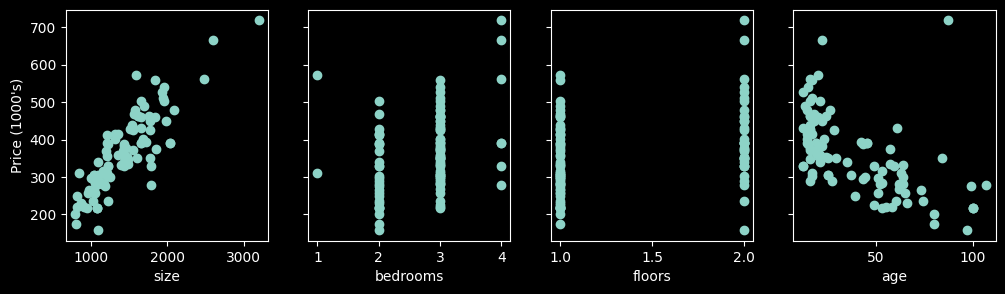

In [44]:

fig,ax=plt.subplots(1, 4, figsize=(12, 3), sharey=True)
for i in range(len(ax)):
    ax[i].scatter(X_train[:,i],y_train)
    ax[i].set_xlabel(X_features[i])
ax[0].set_ylabel("Price (1000's)")
plt.show()

## 2.2 Matrix X containing our examples
Similar to the table above, examples are stored in a NumPy matrix `X_train`. Each row of the matrix represents one example. When you have $m$ training examples ( $m$ is three in our example), and there are $n$ features (four in our example), $\mathbf{X}$ is a matrix with dimensions ($m$, $n$) (m rows, n columns).


$$\mathbf{X} =
\begin{pmatrix}
 x^{(0)}_0 & x^{(0)}_1 & \cdots & x^{(0)}_{n-1} \\
 x^{(1)}_0 & x^{(1)}_1 & \cdots & x^{(1)}_{n-1} \\
 \cdots \\
 x^{(m-1)}_0 & x^{(m-1)}_1 & \cdots & x^{(m-1)}_{n-1}
\end{pmatrix}
$$
notation:
- $\mathbf{x}^{(i)}$ is vector containing example i. $\mathbf{x}^{(i)}$ $ = (x^{(i)}_0, x^{(i)}_1, \cdots,x^{(i)}_{n-1})$
- $x^{(i)}_j$ is element j in example i. The superscript in parenthesis indicates the example number while the subscript represents an element.  

Display the input data.

In [45]:
# data is stored in numpy array/matrix
print(f"X Shape: {X_train.shape}, X Type:{type(X_train)})")
print(f"y Shape: {y_train.shape}, y Type:{type(y_train)})")


X Shape: (99, 4), X Type:<class 'numpy.ndarray'>)
y Shape: (99,), y Type:<class 'numpy.ndarray'>)


<a name="toc_15456_2.2"></a>
## 2.3 Parameter vector w, b

* $\mathbf{w}$ is a vector with $n$ elements.
  - Each element contains the parameter associated with one feature.
  - in our dataset, n is 4.
  - notionally, we draw this as a column vector

$$\mathbf{w} = \begin{pmatrix}
w_0 \\
w_1 \\
\cdots\\
w_{n-1}
\end{pmatrix}
$$
* $b$ is a scalar parameter.  

In [46]:
b_init = 785.1811367994083
w_init = np.array([ 0.39133535, 18.75376741, -53.36032453, -26.42131618])
print(f"w_init shape: {w_init.shape}, b_init type: {type(b_init)}")

w_init shape: (4,), b_init type: <class 'float'>


<a name="toc_15456_3"></a>
# 3 Model Prediction With Multiple Variables
The model's prediction with multiple variables is given by the linear model:

$$ f_{\mathbf{w},b}(\mathbf{x}) =  w_0x_0 + w_1x_1 +... + w_{n-1}x_{n-1} + b \tag{1}$$
or in vector notation:
$$ f_{\mathbf{w},b}(\mathbf{x}) = \mathbf{w} \cdot \mathbf{x} + b  \tag{2} $$
where $\cdot$ is a vector `dot product`

To demonstrate the dot product, we will implement prediction using (1) and (2).

In [47]:
def predict(x, w, b):
    """
    single predict using linear regression
    """
    # SHAFE:JAWAD np.dot computes the dot product of w and x vectors
    # this is w0*x0 + w1*x1 + w2*x2 + w3*x3 + b for 4 features
    # dot product is the KEY operation for multiple features
    p = np.dot(x, w) + b
    return p

SHAFE:JAWAD

The predict function for multiple features. The key operation is np.dot(x, w) which computes the dot product. This replaces the simple w*x we had before. With 4 features, np.dot does w0*x0 + w1*x1 + w2*x2 + w3*x3 all at once.

In [48]:
# get a row from our training data
x_vec = X_train[0,:]
print(f"x_vec shape {x_vec.shape}, x_vec value: {x_vec}")

# make a prediction
f_wb = predict(x_vec,w_init, b_init)
print(f"f_wb shape {f_wb.shape}, prediction: {f_wb}")

x_vec shape (4,), x_vec value: [1.24e+03 3.00e+00 1.00e+00 6.40e+01]
f_wb shape (), prediction: -416.06094562059184


<a name="toc_15456_4"></a>
# 4 Compute Cost With Multiple Variables
The equation for the cost function with multiple variables $J(\mathbf{w},b)$ is:
$$J(\mathbf{w},b) = \frac{1}{2m} \sum\limits_{i = 0}^{m-1} (f_{\mathbf{w},b}(\mathbf{x}^{(i)}) - y^{(i)})^2 \tag{3}$$
where:
$$ f_{\mathbf{w},b}(\mathbf{x}^{(i)}) = \mathbf{w} \cdot \mathbf{x}^{(i)} + b  \tag{4} $$


In contrast to tje previous exercise, $\mathbf{w}$ and $\mathbf{x}^{(i)}$ are vectors rather than scalars supporting multiple features.

In [49]:
def compute_cost(X, y, w, b):
    """
    compute cost for multiple features
    """
    # SHAFE:JAWAD same cost function as before but now X is a matrix not a vector
    # we loop through each example, compute dot product prediction, then squared error
    # this is the NONVECTORIZED way, slow but easy to understand
    m = X.shape[0]
    cost = 0.0
    for i in range(m):
        f_wb_i = np.dot(X[i], w) + b
        cost = cost + (f_wb_i - y[i])**2
    cost = cost / (2 * m)
    return cost

SHAFE:JAWAD

The cost function for multiple features. Same idea as before but now we use np.dot for predictions. We still loop through all examples, compute squared error, and average. This is the nonvectorized version which is slow but easy to understand.

In [50]:
# Compute and display cost using our pre-chosen optimal parameters.
cost = compute_cost(X_train, y_train, w_init, b_init)
print(f'Cost at initial w,b: {cost}')

Cost at initial w,b: 222294.83925913335


<a name="toc_15456_5"></a>
# 5 Gradient Descent With Multiple Variables
Gradient descent for multiple variables:

$$\begin{align*} \text{repeat}&\text{ until convergence:} \; \lbrace \newline\;
& w_j = w_j -  \alpha \frac{\partial J(\mathbf{w},b)}{\partial w_j} \tag{5}  \; & \text{for j = 0..n-1}\newline
&b\ \ = b -  \alpha \frac{\partial J(\mathbf{w},b)}{\partial b}  \newline \rbrace
\end{align*}$$

where, n is the number of features, parameters $w_j$,  $b$, are updated simultaneously and where  

$$
\begin{align}
\frac{\partial J(\mathbf{w},b)}{\partial w_j}  &= \frac{1}{m} \sum\limits_{i = 0}^{m-1} (f_{\mathbf{w},b}(\mathbf{x}^{(i)}) - y^{(i)})x_{j}^{(i)} \tag{6}  \\
\frac{\partial J(\mathbf{w},b)}{\partial b}  &= \frac{1}{m} \sum\limits_{i = 0}^{m-1} (f_{\mathbf{w},b}(\mathbf{x}^{(i)}) - y^{(i)}) \tag{7}
\end{align}
$$
* m is the number of training examples in the data set

    
*  $f_{\mathbf{w},b}(\mathbf{x}^{(i)})$ is the model's prediction, while $y^{(i)}$ is the target value


In [51]:
def compute_gradient(X, y, w, b):
    """
    Computes the gradient for linear regression with multiple features
    """
    # SHAFE:JAWAD gradient now returns a VECTOR dj_dw with one value per feature
    # we need partial derivative for each weight w0 w1 w2 w3
    # inner loop goes through each feature j, outer loop through each example i
    m,n = X.shape
    dj_dw = np.zeros((n,))
    dj_db = 0.

    for i in range(m):
        err = (np.dot(X[i], w) + b) - y[i]
        for j in range(n):
            dj_dw[j] = dj_dw[j] + err * X[i, j]
        dj_db = dj_db + err
    dj_dw = dj_dw / m
    dj_db = dj_db / m

    return dj_db, dj_dw

SHAFE:JAWAD

The gradient function for multiple features. Now we return a VECTOR of gradients, one for each weight. The outer loop goes through examples, the inner loop goes through features. For each feature j we compute how much that weight contributes to the error.

In [52]:
#Compute and display gradient
tmp_dj_db, tmp_dj_dw = compute_gradient(X_train, y_train, w_init, b_init)
print(f'dj_db at initial w,b: {tmp_dj_db}')
print(f'dj_dw at initial w,b: \n {tmp_dj_dw}')

dj_db at initial w,b: -59.762118071904915
dj_dw at initial w,b: 
 [ 1.47e+04 -9.89e+01  1.69e+00 -1.93e+04]


In [53]:
def gradient_descent(X, y, w_in, b_in, cost_function, gradient_function, alpha, num_iters):
    """
    Performs batch gradient descent for multiple features
    """
    # SHAFE:JAWAD same gradient descent but w is now a vector not scalar
    # we update ALL weights simultaneously in each iteration
    # the update w = w - alpha*dj_dw works element wise on the weight vector

    J_history = []
    w = copy.deepcopy(w_in)
    b = b_in

    for i in range(num_iters):
        dj_db,dj_dw = gradient_function(X, y, w, b)

        w = w - alpha * dj_dw
        b = b - alpha * dj_db

        if i<100000:
            J_history.append( cost_function(X, y, w, b))

        if i% math.ceil(num_iters / 10) == 0:
            print(f"Iteration {i:4d}: Cost {J_history[-1]:8.2f}   ")

    return w, b, J_history

## 5.1 Runing Gradient Descent

In [54]:
# SHAFE:JAWAD FIRST TRY without normalization, cost EXPLODES to infinity
# this happens because features have very different scales (size in 1000s vs floors 1-2)
# gradient descent cant handle this, steps are too big for large features
initial_w = np.zeros_like(w_init)
initial_b = 0.
iterations = 100
alpha = 0.1

w_final, b_final, J_hist = gradient_descent(X_train, y_train, initial_w, initial_b,
                                                    compute_cost, compute_gradient,
                                                    alpha, iterations)
print(f"b,w found by gradient descent: {b_final:0.2f},{w_final} ")
m,_ = X_train.shape
for i in range(3):
    print(f"prediction: {np.dot(X_train[i], w_final) + b_final:0.2f}, target value: {y_train[i]}")

Iteration    0: Cost 3324052819830532.50   
Iteration   10: Cost 199755424983554075038069242162278325843853508248686021531176265539374029270210830202580645660688785627041754986122032709632.00   
Iteration   20: Cost 12004090186708107493141244322016080951677489022807771721751747819576996910717838831063162774115878417957851401985386782815669903214715912248410558147713912301655708247515291181348904976556533665297478241930152943682663780565647360.00   
Iteration   30: Cost      inf   
Iteration   40: Cost      inf   
Iteration   50: Cost      inf   
Iteration   60: Cost      nan   
Iteration   70: Cost      nan   
Iteration   80: Cost      nan   
Iteration   90: Cost      nan   
b,w found by gradient descent: nan,[nan nan nan nan] 
prediction: nan, target value: 300.0
prediction: nan, target value: 509.8
prediction: nan, target value: 394.0


/var/folders/0l/3qw34ws157j1ks8n0s5zxh440000gn/T/ipykernel_24471/2832390231.py:12: RuntimeWarning: overflow encountered in scalar power
  cost = cost + (f_wb_i - y[i])**2
/var/folders/0l/3qw34ws157j1ks8n0s5zxh440000gn/T/ipykernel_24471/1462777781.py:15: RuntimeWarning: overflow encountered in scalar multiply
  dj_dw[j] = dj_dw[j] + err * X[i, j]
/var/folders/0l/3qw34ws157j1ks8n0s5zxh440000gn/T/ipykernel_24471/1462777781.py:15: RuntimeWarning: overflow encountered in scalar add
  dj_dw[j] = dj_dw[j] + err * X[i, j]
/var/folders/0l/3qw34ws157j1ks8n0s5zxh440000gn/T/ipykernel_24471/1462777781.py:16: RuntimeWarning: overflow encountered in scalar add
  dj_db = dj_db + err
/var/folders/0l/3qw34ws157j1ks8n0s5zxh440000gn/T/ipykernel_24471/458153452.py:16: RuntimeWarning: invalid value encountered in subtract
  w = w - alpha * dj_dw
/var/folders/0l/3qw34ws157j1ks8n0s5zxh440000gn/T/ipykernel_24471/458153452.py:17: RuntimeWarning: invalid value encountered in scalar subtract
  b = b - alpha * dj_

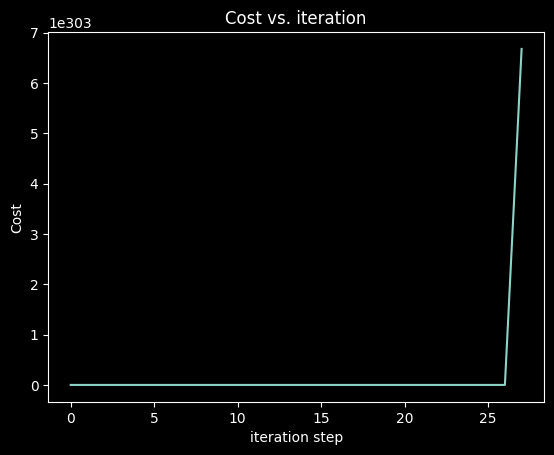

In [55]:
# plot cost versus iteration
plt.plot(J_hist)
plt.title("Cost vs. iteration")
plt.ylabel('Cost')
plt.xlabel('iteration step')
plt.show()

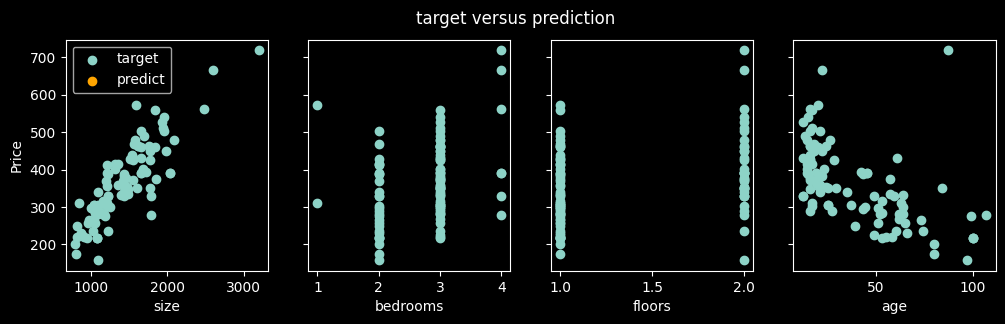

In [56]:
#predict target using normalized features
m = X_train.shape[0]
yp = np.zeros(m)
for i in range(m):
    yp[i] = np.dot(X_train[i], w_final) + b_final

    # plot predictions and targets versus original features
fig,ax=plt.subplots(1,4,figsize=(12, 3),sharey=True)
for i in range(len(ax)):
    ax[i].scatter(X_train[:,i],y_train, label = 'target')
    ax[i].set_xlabel(X_features[i])
    ax[i].scatter(X_train[:,i],yp,color="orange", label = 'predict')
ax[0].set_ylabel("Price"); ax[0].legend();
fig.suptitle("target versus prediction")
plt.show()

# 6 Feature Scaling


## 6.2 Z-score normalization

After z-score normalization, all features will have a mean of 0 and a standard deviation of 1.

To implement z-score normalization, adjust your input values as shown in this formula:
$$x^{(i)}_j = \dfrac{x^{(i)}_j - \mu_j}{\sigma_j} \tag{4}$$
where $j$ selects a feature or a column in the $\mathbf{X}$ matrix. $µ_j$ is the mean of all the values for feature (j) and $\sigma_j$ is the standard deviation of feature (j).
$$
\begin{align}
\mu_j &= \frac{1}{m} \sum_{i=0}^{m-1} x^{(i)}_j \tag{5}\\
\sigma^2_j &= \frac{1}{m} \sum_{i=0}^{m-1} (x^{(i)}_j - \mu_j)^2  \tag{6}
\end{align}
$$

>**Implementation Note:** When normalizing the features, it is important
to store the values used for normalization - the mean value and the standard deviation used for the computations. After learning the parameters
from the model, we often want to predict the prices of houses we have not
seen before. Given a new x value (living room area and number of bed-
rooms), we must first normalize x using the mean and standard deviation
that we had previously computed from the training set.

**Implementation**

In [57]:
def zscore_normalize_features(X):
    """
    computes X, zcore normalized by column
    """
    # SHAFE:JAWAD Z-SCORE NORMALIZATION is essential for gradient descent
    # we subtract mean and divide by standard deviation for each feature
    # after this all features have mean=0 and std=1, same scale
    # this makes gradient descent converge properly
    X_mean     = np.mean(X, axis=0)
    X_sigma  = np.std(X, axis=0)
    X_norm = (X - X_mean) / X_sigma

    return (X_norm, X_mean, X_sigma)

SHAFE:JAWAD

Z-SCORE NORMALIZATION is CRITICAL for multiple features. Without it, gradient descent fails because features have wildly different scales. Size might be 1000-2000 while floors is 1-2. Normalization puts everything on the same scale with mean 0 and standard deviation 1.

Apply data normalization

In [58]:
X_norm, X_mean, X_sigma = zscore_normalize_features(X_train)

Plotting the data after normalization (compare with the output of Section 2.1)

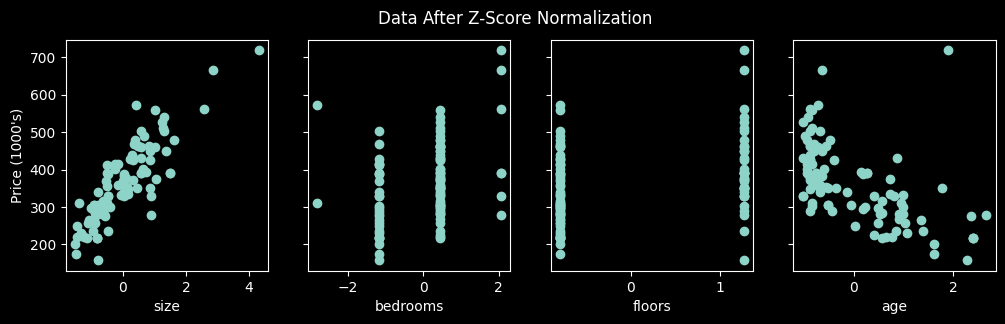

In [59]:
fig,ax=plt.subplots(1, 4, figsize=(12, 3), sharey=True)
for i in range(len(ax)):
    ax[i].scatter(X_norm[:,i],y_train)
    ax[i].set_xlabel(X_features[i])

ax[0].set_ylabel("Price (1000's)")
fig.suptitle("Data After Z-Score Normalization")
plt.show()

## 6.2 Runing Gradient Descent after Feature Scaling

In [60]:
# SHAFE:JAWAD NOW with normalized features, gradient descent works perfectly
# cost goes down smoothly instead of exploding
# same alpha=0.1 now works because all features are on same scale
initial_w = np.zeros_like(w_init)
initial_b = 0.
iterations = 1000
alpha = 0.1

w_final, b_final, J_hist = gradient_descent(X_norm, y_train, initial_w, initial_b,
                                                    compute_cost, compute_gradient,
                                                    alpha, iterations)
print(f"b,w found by gradient descent: {b_final:0.2f},{w_final} ")
m,_ = X_train.shape
for i in range(3):
    print(f"prediction: {np.dot(X_norm[i], w_final) + b_final:0.2f}, target value: {y_train[i]}")

Iteration    0: Cost 57590.74   
Iteration  100: Cost   233.57   
Iteration  200: Cost   230.81   
Iteration  300: Cost   230.81   
Iteration  400: Cost   230.81   
Iteration  500: Cost   230.81   
Iteration  600: Cost   230.81   
Iteration  700: Cost   230.81   
Iteration  800: Cost   230.81   
Iteration  900: Cost   230.81   
b,w found by gradient descent: 363.16,[111.55 -21.11 -33.21 -38.1 ] 
prediction: 294.91, target value: 300.0
prediction: 486.62, target value: 509.8
prediction: 389.50, target value: 394.0


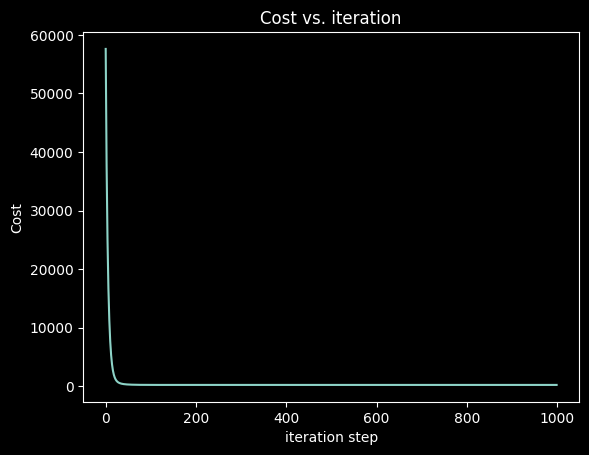

In [61]:
# plot cost versus iteration
plt.plot(J_hist[0:])
plt.title("Cost vs. iteration")
plt.ylabel('Cost')
plt.xlabel('iteration step')
plt.show()

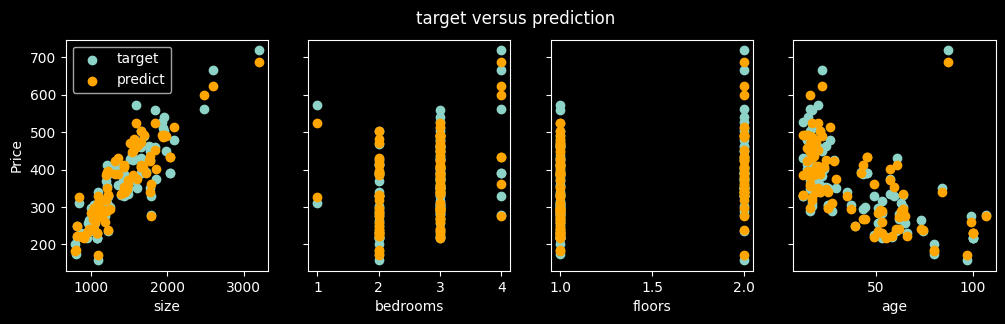

In [62]:
#predict target using normalized features
m = X_norm.shape[0]
yp = np.zeros(m)
for i in range(m):
    yp[i] = np.dot(X_norm[i], w_final) + b_final

    # plot predictions and targets versus original features
fig,ax=plt.subplots(1,4,figsize=(12, 3),sharey=True)
for i in range(len(ax)):
    ax[i].scatter(X_train[:,i],y_train, label = 'target')
    ax[i].set_xlabel(X_features[i])
    ax[i].scatter(X_train[:,i],yp,color="orange", label = 'predict')
ax[0].set_ylabel("Price"); ax[0].legend();
fig.suptitle("target versus prediction")
plt.show()

## Exercise 1: Explore the effect of feature scaling in Gradient Descent

Perform the following experiments:

* Observe how the learning rate has different effects before and after normalization.

* Observe how quickly gradient descent converges depending of the learning rate before and after normalization.


SHAFE:JAWAD

For this exercise we need to experiment with learning rates before and after normalization.
First run gradient descent on the raw unnormalized data with different learning rates like 0.0001 and 0.1.
Then normalize the features and try the same learning rates.
We should see that without normalization only tiny learning rates work, and even then convergence is slow.
After normalization we can use bigger learning rates and gradient descent converges much faster.
This shows WHY normalization is so important.


---
SUBMIT FEEDBACK


---



---




In [63]:
feedback("session8_MLR_Exercise1", finished=True, understood=False, comment="No comments")

FEEDBACK SUBMITTED. THANKS!!! :D


# 7 Feature Engineering

Let us introduce in our training data sample a new feature "size_per_bedrrom":

$$ \text{size_per_bedroom} = \frac{\text{size}}{\text{number of bedrooms}}$$

In [79]:
# SHAFE:JAWAD FEATURE ENGINEERING: creating new features from existing ones
# here we add size_per_bedroom = size / bedrooms as a new feature
# this might capture useful information the original features dont show alone
X_train_extended = np.zeros((X_train.shape[0],X_train.shape[1]+1))
X_train_extended[:,:-1] = X_train
X_train_extended[:,-1] = X_train[:,0]/(X_train[:,1])
X_features_extended = ['size','bedrooms','floors','age','size_per_bedroom']

Let us look how the new data set looks like:

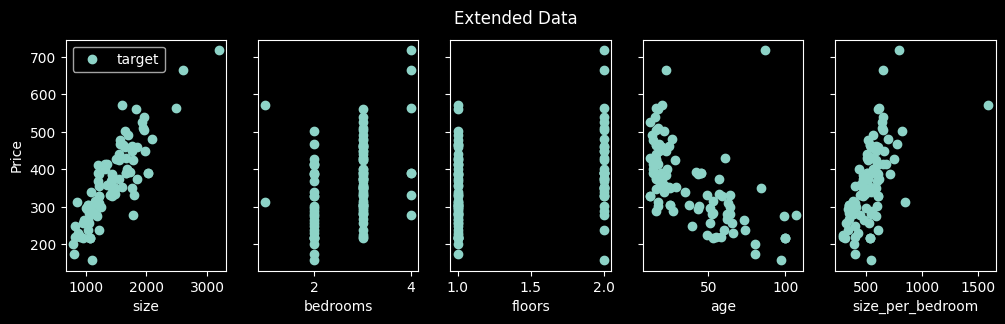

In [65]:
#predict target using normalized features
m = X_train_extended.shape[0]

# plot predictions and targets versus original features
fig,ax=plt.subplots(1,len(X_features_extended),figsize=(12, 3),sharey=True)
for i in range(len(ax)):
    ax[i].scatter(X_train_extended[:,i],y_train, label = 'target')
    ax[i].set_xlabel(X_features_extended[i])
ax[0].set_ylabel("Price"); ax[0].legend();
fig.suptitle("Extended Data")
plt.show()

Let us normalize the new data set

In [66]:
X_norm, X_mean, X_sigma = zscore_normalize_features(X_train_extended)

Let us learn with the new data set

In [67]:
# initialize parameters
initial_w = np.zeros(X_norm.shape[1])
initial_b = 0.
# some gradient descent settings
iterations = 1000
alpha = 0.1
# run gradient descent
w_final, b_final, J_hist = gradient_descent(X_norm, y_train, initial_w, initial_b,
                                                    compute_cost, compute_gradient,
                                                    alpha, iterations)
print(f"b,w found by gradient descent: {b_final:0.2f},{w_final} ")
m,_ = X_train.shape
for i in range(3):
    print(f"prediction: {np.dot(X_norm[i], w_final) + b_final:0.2f}, target value: {y_train[i]}")

Iteration    0: Cost 57256.32   
Iteration  100: Cost   275.70   
Iteration  200: Cost   245.13   
Iteration  300: Cost   233.66   
Iteration  400: Cost   229.35   
Iteration  500: Cost   227.73   
Iteration  600: Cost   227.12   
Iteration  700: Cost   226.89   
Iteration  800: Cost   226.80   
Iteration  900: Cost   226.77   
b,w found by gradient descent: 363.16,[103.89 -13.95 -32.68 -37.65   7.29] 
prediction: 295.92, target value: 300.0
prediction: 485.49, target value: 509.8
prediction: 389.57, target value: 394.0


Let us inspect the learning results of the new data set

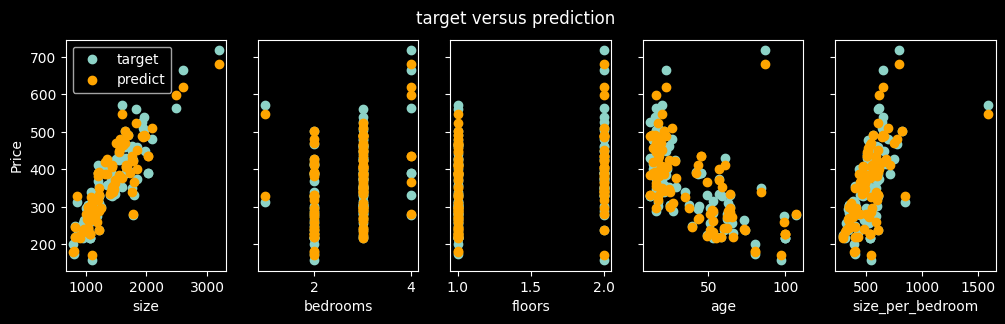

In [68]:
#predict target using normalized features
m = X_norm.shape[0]
yp = np.zeros(m)
for i in range(m):
    yp[i] = np.dot(X_norm[i], w_final) + b_final

    # plot predictions and targets versus original features
fig,ax=plt.subplots(1,5,figsize=(12, 3),sharey=True)
for i in range(len(ax)):
    ax[i].scatter(X_train_extended[:,i],y_train, label = 'target')
    ax[i].set_xlabel(X_features_extended[i])
    ax[i].scatter(X_train_extended[:,i],yp,color="orange", label = 'predict')
ax[0].set_ylabel("Price"); ax[0].legend();
fig.suptitle("target versus prediction")
plt.show()

## Exercise 2: Add a new feature and see what happens

* Add a new feature you think it could help to better predict the price of a house, following the same approach used to add "size_per_bedroom" feature. (i) Justify why did you decided to use this feature? (ii) Explore the training cost of the new solution an compare it with the cost of the previous solutions. Is the cost smaller?



SHAFE:JAWAD

For this exercise we need to create a new feature that might help predict house prices better.
Think about what combinations of existing features might be useful. Some ideas:
- age_per_floor = age / floors (older single story houses might be valued differently)
- total_rooms = bedrooms * floors (rough estimate of total space)
- size_times_floors = size * floors (bigger multi-story houses)
After adding the new feature, normalize everything and run gradient descent.
Compare the final cost with the previous solution. Lower cost means the new feature helped.
But watch out for overfitting, more features isnt always better.


---
SUBMIT FEEDBACK


---



---




In [69]:
feedback("session8_MLR_Exercise2", finished=True, understood=True, comment="No comments")

FEEDBACK SUBMITTED. THANKS!!! :D


# 8 Overfitting



## 8.1 Adding Polynomial Features

Let us add new polynomial features (i.e. $size^2$, $size^3$, etc) to our training data set and see what happens with the cost funciton after running gradient descent.

SHAFE:JAWAD

OVERFITTING SECTION. This is where we learn that more features are not always better. Adding polynomial features like size squared or size cubed can help the model fit more complex patterns, but going too high leads to overfitting where the model memorizes training data but fails on new data.

In [70]:
# SHAFE:JAWAD POLYNOMIAL FEATURES: adding size^2, size^3, etc
# higher degree polynomials can fit more complex patterns
# BUT careful: too high degree leads to OVERFITTING
# the model memorizes training data but fails on new data
degree = 2

X_train, y_train = load_house_data()
X_train, _, _ = zscore_normalize_features(X_train)
X_train_extended = np.zeros((X_train.shape[0],X_train.shape[1]+degree-1))

if  degree>1:
  X_train_extended[:,:-(degree-1)] = X_train
else:
  X_train_extended = X_train

X_features_extended = ['size','bedrooms','floors','age']

for d in range(2,degree+1):
  X_train_extended[:,X_train.shape[1] + d-2] = X_train[:,0]**d
  X_features_extended.append("size^"+str(d))

X_train_extended,_,_ = zscore_normalize_features(X_train_extended)

##  Exercise 3: Polynomial Features

- Add polynomial features using the code above. Start with degree=2 and move to degree=20.

- Look how the Cost function is reduced.

- Do you think we are doing better by having more polynomial functions?

SHAFE:JAWAD

For this exercise we experiment with polynomial features of different degrees.
Start with degree=2 which adds size^2. Then try 5, 10, up to 20.
Each time we run gradient descent and look at the final cost.
Higher degrees give lower training cost because the model can fit more complex patterns.
BUT this is a trap. The cost keeps going down but the model is just memorizing the data.
With degree=20 we have 23 features for only 99 examples. Thats way too many parameters.
The key insight: lower cost on training data doesnt mean the model is actually better.

In [71]:
# initialize parameters
initial_w = np.zeros(X_train_extended.shape[1])
initial_b = 0.
# some gradient descent settings
iterations = 1000
alpha = 0.1
# run gradient descent
w_final, b_final, J_hist = gradient_descent(X_train_extended, y_train, initial_w, initial_b,
                                                    compute_cost, compute_gradient,
                                                    alpha, iterations)
print(f"b,w found by gradient descent: {b_final:0.2f},{w_final} ")
m,_ = X_train.shape
for i in range(3):
    print(f"prediction: {np.dot(X_train_extended[i], w_final) + b_final:0.2f}, target value: {y_train[i]}")

Iteration    0: Cost 57447.66   
Iteration  100: Cost   231.80   
Iteration  200: Cost   221.70   
Iteration  300: Cost   221.56   
Iteration  400: Cost   221.56   
Iteration  500: Cost   221.56   
Iteration  600: Cost   221.56   
Iteration  700: Cost   221.56   
Iteration  800: Cost   221.56   
Iteration  900: Cost   221.56   
b,w found by gradient descent: 363.16,[107.44 -20.87 -32.42 -40.06   5.61] 
prediction: 292.02, target value: 300.0
prediction: 485.78, target value: 509.8
prediction: 386.09, target value: 394.0



---
SUBMIT FEEDBACK


---



---




In [72]:
feedback("session8_MLR_Exercise3", finished=True, understood=True, comment="No comments")

FEEDBACK SUBMITTED. THANKS!!! :D


## 8.2 Measuring Overfitting

We now split the data set in training data set and validation data set.  

SHAFE:JAWAD

DETECTING OVERFITTING using train/validation split. We split data into training set and test set. If training cost is low but test cost is high, thats overfitting. The model learned the training data too well but cant generalize to new examples.

In [73]:
# SHAFE:JAWAD SPLITTING DATA into training and validation sets
# we train on 66 examples and test on the rest
# this lets us detect OVERFITTING: if training cost is low but test cost is high
# that means model memorized training data but doesnt generalize
np.random.seed(123)
perm = np.random.permutation(X_train_extended.shape[0])
X_train_extended = X_train_extended[perm,:]
y_train = y_train[perm]

size_train = 66
X_split_train, y_split_train = X_train_extended[0:size_train,:], y_train[0:size_train]
X_split_val, y_split_val = X_train_extended[size_train:,:], y_train[size_train:]

Let us plot both data sets

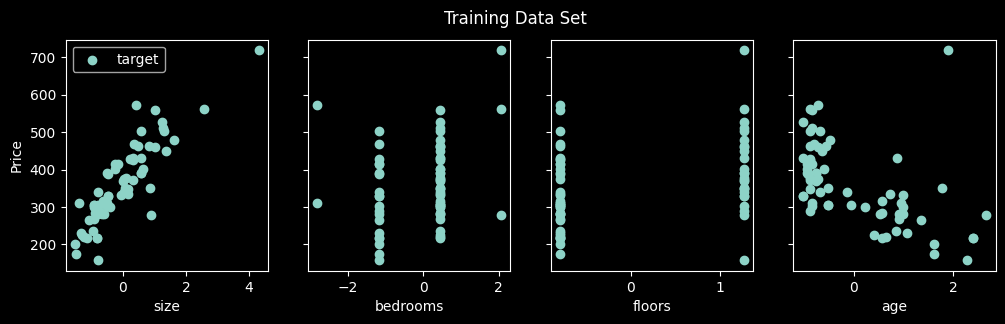

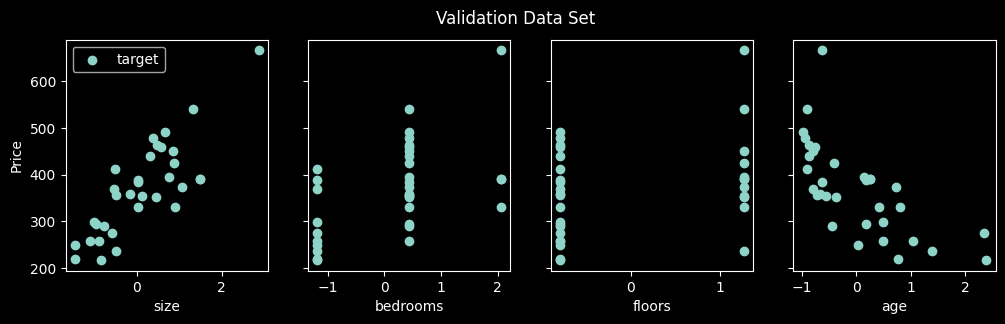

In [74]:
# plot the training data set
fig,ax=plt.subplots(1,4,figsize=(12, 3),sharey=True)
for i in range(len(ax)):
    ax[i].scatter(X_split_train[:,i],y_split_train, label = 'target')
    ax[i].set_xlabel(X_features[i])
ax[0].set_ylabel("Price"); ax[0].legend();
fig.suptitle("Training Data Set")
plt.show()


# plot predictions and targets versus original features
fig,ax=plt.subplots(1,4,figsize=(12, 3),sharey=True)
for i in range(len(ax)):
    ax[i].scatter(X_split_val[:,i],y_split_val, label = 'target')
    ax[i].set_xlabel(X_features[i])
ax[0].set_ylabel("Price"); ax[0].legend();
fig.suptitle("Validation Data Set")
plt.show()



The function below implements gradient descent, but it computes both the cost for the training data set and for the validation data set

In [75]:
def gradient_descent_val(X, y, X_val, y_val, w_in, b_in, cost_function, gradient_function, alpha, num_iters):
    """
    Performs batch gradient descent to learn theta. Updates theta by taking
    num_iters gradient steps with learning rate alpha


    Args:
      X (ndarray (m,n))   : Data, m examples with n features
      y (ndarray (m,))    : target values
      w_in (ndarray (n,)) : initial model parameters
      b_in (scalar)       : initial model parameter
      cost_function       : function to compute cost
      gradient_function   : function to compute the gradient
      alpha (float)       : Learning rate
      num_iters (int)     : number of iterations to run gradient descent

    Returns:
      w (ndarray (n,)) : Updated values of parameters
      b (scalar)       : Updated value of parameter
      """

    # An array to store cost J and w's at each iteration primarily for graphing later
    J_history_train = []
    J_history_test = []
    w = copy.deepcopy(w_in)  #avoid modifying global w within function
    b = b_in

    for i in range(num_iters):

        # Calculate the gradient and update the parameters
        dj_db,dj_dw = gradient_function(X, y, w, b)   ##None

        # Update Parameters using w, b, alpha and gradient
        w = w - alpha * dj_dw               ##None
        b = b - alpha * dj_db               ##None

        # Save cost J at each iteration
        if i<100000:      # prevent resource exhaustion
            J_history_train.append( cost_function(X, y, w, b))
            J_history_test.append( cost_function(X_val, y_val, w, b))

        # Print cost every at intervals 10 times or as many iterations if < 10
        if i% math.ceil(num_iters / 10) == 0:
            print(f"Iteration {i:4d}: Training Cost {J_history_train[-1]:8.2f}, Test cost {J_history_test[-1]:8.2f}   ")

    return w, b, J_history_train, J_history_test

##  Exercise 4: Measuing Training and Test Error

- Add polynomial features using the code above. Start with degree=2 and move to degree=20.

- Look how the Cost function for the training and the test set evolves.

- Increase and decrease the number of iterations for gradient descent (move it from 10000 to 20000) and observed what happens with the the training and the test cost.

- What do you think is happening?

- Which should be the degree of the included polynomial features?

SHAFE:JAWAD

This exercise shows how to detect overfitting by comparing training cost vs test cost.
Try different polynomial degrees (2 to 20) and watch both curves.
At low degrees both costs are similar. Model is too simple but generalizes ok.
As degree increases training cost drops but test cost starts going UP. Thats overfitting.
Also try increasing iterations from 10000 to 20000. With high degree polynomials more iterations makes overfitting worse.
The sweet spot is where test cost is lowest, not where training cost is lowest.
This is the most important lesson: always evaluate on data the model hasnt seen during training.

In [76]:
# initialize parameters
initial_w = np.zeros(X_split_train.shape[1])
initial_b = 0.
# some gradient descent settings
iterations = 10000
alpha = 0.01
# run gradient descent
w_final, b_final, J_hist_train, J_history_test = gradient_descent_val(X_split_train, y_split_train, X_split_val, y_split_val, initial_w, initial_b,
                                                    compute_cost, compute_gradient,
                                                    alpha, iterations)
print(f"b,w found by gradient descent: {b_final:0.2f},{w_final} ")
m,_ = X_train.shape
for i in range(3):
    print(f"prediction: {np.dot(X_split_train[i], w_final) + b_final:0.2f}, target value: {y_train[i]}")

Iteration    0: Training Cost 69136.08, Test cost 71519.58   
Iteration 1000: Training Cost   223.03, Test cost   250.13   
Iteration 2000: Training Cost   211.78, Test cost   263.32   
Iteration 3000: Training Cost   211.67, Test cost   265.37   
Iteration 4000: Training Cost   211.67, Test cost   265.58   
Iteration 5000: Training Cost   211.67, Test cost   265.61   
Iteration 6000: Training Cost   211.67, Test cost   265.61   
Iteration 7000: Training Cost   211.67, Test cost   265.61   
Iteration 8000: Training Cost   211.67, Test cost   265.61   
Iteration 9000: Training Cost   211.67, Test cost   265.61   
b,w found by gradient descent: 365.00,[109.22 -18.58 -32.83 -37.67   2.21] 
prediction: 703.51, target value: 718.2
prediction: 513.23, target value: 480.0
prediction: 372.43, target value: 334.0


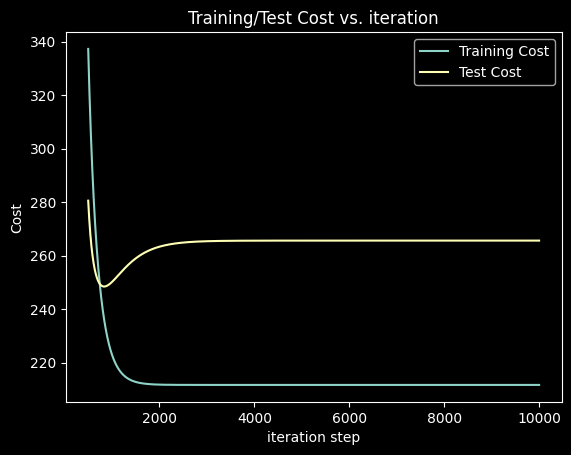

In [77]:
# plot cost versus iteration
start = 500
plt.plot(np.arange(start,iterations,1), J_hist_train[start:], label = "Training Cost")
plt.plot(np.arange(start,iterations,1), J_history_test[start:], label = "Test Cost")
plt.title("Training/Test Cost vs. iteration")
plt.ylabel('Cost')
plt.xlabel('iteration step')
plt.legend()
plt.show()


---
SUBMIT FEEDBACK


---



---




In [78]:
feedback("session8_MLR_Exercise4", finished=True, understood=True, comment="No comments")

FEEDBACK SUBMITTED. THANKS!!! :D


SHAFE:JAWAD
WHAT WE HAVE LEARNED

1. Multiple linear regression uses VECTORS instead of scalars. The weight w becomes a vector with one value per feature, and we use dot products for predictions.

2. The predict function uses np.dot(x, w) + b to compute the weighted sum of all features at once. This replaces the simple w*x from single feature regression.

3. Cost and gradient functions are the same formulas but now loop through multiple features. Each weight gets its own gradient telling it which direction to move.

4. Without feature scaling gradient descent FAILS on multiple features. Features like size (1000s) and floors (1-2) have wildly different scales that mess up the gradients.

5. Z-SCORE NORMALIZATION fixes this by subtracting mean and dividing by std for each feature. After normalization everything has mean 0 and std 1.

6. FEATURE ENGINEERING means creating new features from existing ones. Size per bedroom might capture info that size and bedrooms alone dont show.

7. POLYNOMIAL FEATURES like size^2 or size^3 let us capture non-linear patterns. But too many leads to overfitting.

8. OVERFITTING happens when training cost is low but test cost is high. The model memorized training data but cant generalize.

9. Always split data into training and test sets to detect overfitting. The test set cost tells you how well the model actually works.

10. The bias-variance tradeoff: simple models underfit (high bias), complex models overfit (high variance). We want the sweet spot in between.